In [1]:
from probcs.experiment_running.exc_experiment import exc_exponent_experiment
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def plot_posterior_half(G_dim, disrupting_pattern_indices, all_idata):
    """
    Plots posterior distributions of latent variables G and X for MEI,
    Completing, and two Disrupting patterns.

    Parameters:
    - G_dim (int): Dimension of the latent variable G.
    - disrupting_pattern_indices (list): List of indices corresponding to disrupting patterns.
    - all_idata (list): List containing InferenceData objects for MEI, Completing, and Disrupting 1 and Disrupting 2 patterns.

    Returns:
    - fig (matplotlib.figure.Figure): The Matplotlib figure object containing the generated plot.
    - axs (numpy.ndarray): 2D array of Matplotlib axes objects representing subplots in the figure.

    Each row of subplots corresponds to a different latent variable, and each column represents
    a specific aspect of the analysis (e.g., marginal distributions, G variable distributions).

    The function visualizes the posterior distributions of latent variables for MEI, Completing,
    and Disrupting patterns, comparing their means and percentage differences. The plot includes
    histograms, bar plots, and descriptive statistics to aid in the interpretation of the model results.
    """

    fig, axs = plt.subplots(
        G_dim,
        2,
        figsize=((2 + 3) * 2, (G_dim + 3) * 2),
        tight_layout=True,
        sharex="col",
    )
    legend_size = 10
    possible_center_x_ids = [4 * G_dim + i for i in range(G_dim)]
    completing_perc_diff_list = []
    disrupting_1_perc_diff_list = []
    disrupting_2_perc_diff_list = []
    for idx, (ax_set, idata_set, disrupting_pattern_idx) in enumerate(
        zip(axs, all_idata, disrupting_pattern_indices)
    ):
        center_x_id = 4 * G_dim + idx
        # i for i in range(idx, G_dim)
        completing_surround_x_ids = [
            i for i in range(idx, 9 * G_dim, G_dim) if i != center_x_id
        ]
        # complement of completing_surround_x_ids
        not_completing_surround_x_ids = [
            i
            for i in range(9 * G_dim)
            if (i not in completing_surround_x_ids) and (i != center_x_id)
        ]
        disrupting_surround_x_ids = [
            i
            for i in range(disrupting_pattern_idx, 9 * G_dim, G_dim)
            if i not in possible_center_x_ids
        ]
        # complement of disrupting_surround_x_ids
        not_disrupting_surround_x_ids = [
            i
            for i in range(9 * G_dim)
            if (i not in disrupting_surround_x_ids) and (i != center_x_id)
        ]
        print(not_disrupting_surround_x_ids)

        # idata['posterior']['X'].data.shape = (n_chains, n_samples, n_x_dims)
        mei_idata = idata_set[0]
        completing_idata = idata_set[1]
        disrupting_1_idata = idata_set[2]
        disrupting_2_idata = idata_set[3]

        mei_x_samples = mei_idata["posterior"]["X"].data[:, :, center_x_id].flatten()
        mei_x_mean = mei_x_samples.mean()
        sns.histplot(
            mei_x_samples,
            ax=ax_set[0],
            stat="density",
            color="blue",
            element="step",
            alpha=0.3,
            label="MEI",
        )

        # mei_idata["posterior"]["G"].data.shape = (n_chains, n_samples, n_G_dims)
        mei_g_samples = mei_idata["posterior"]["G"].data.mean(axis=0).mean(axis=0)
        # mei_g_samples.shape = (n_G_dims,)

        completing_x_samples = (
            completing_idata["posterior"]["X"].data[:, :, center_x_id].flatten()
        )
        completing_x_mean = completing_x_samples.mean()
        completing_perc_diff = (completing_x_mean - mei_x_mean) / mei_x_mean * 100
        completing_perc_diff_list.append(completing_perc_diff)
        sns.histplot(
            completing_x_samples,
            ax=ax_set[0],
            stat="density",
            color="green",
            element="step",
            alpha=0.3,
            label="Completing",
        )

        completing_g_samples = (
            completing_idata["posterior"]["G"].data.mean(axis=0).mean(axis=0)
        )

        disrupting_1_x_samples = (
            disrupting_1_idata["posterior"]["X"].data[:, :, center_x_id].flatten()
        )
        disrupting_1_x_mean = disrupting_1_x_samples.mean()
        disrupting_1_perc_diff = (disrupting_1_x_mean - mei_x_mean) / mei_x_mean * 100
        disrupting_1_perc_diff_list.append(disrupting_1_perc_diff)
        sns.histplot(
            disrupting_1_x_samples,
            ax=ax_set[0],
            stat="density",
            color="brown",
            element="step",
            alpha=0.3,
            label="Disrupting 1",
        )

        disrupting_1_g_samples = (
            disrupting_1_idata["posterior"]["G"].data.mean(axis=0).mean(axis=0)
        )

        disrupting_2_x_samples = (
            disrupting_2_idata["posterior"]["X"].data[:, :, center_x_id].flatten()
        )
        disrupting_2_x_mean = disrupting_2_x_samples.mean()
        disrupting_2_perc_diff = (disrupting_2_x_mean - mei_x_mean) / mei_x_mean * 100
        disrupting_2_perc_diff_list.append(disrupting_2_perc_diff)
        sns.histplot(
            disrupting_2_x_samples,
            ax=ax_set[0],
            stat="density",
            color="red",
            element="step",
            alpha=0.3,
            label="Disrupting 2",
        )

        disrupting_2_g_samples = (
            disrupting_2_idata["posterior"]["G"].data.mean(axis=0).mean(axis=0)
        )

        ax_set[1].bar(x=np.arange(G_dim), height=mei_g_samples, width=0.8, color="blue")
        ax_set[1].bar(
            x=np.arange(G_dim) + G_dim,
            height=completing_g_samples,
            width=0.8,
            color="green",
        )
        ax_set[1].bar(
            x=np.arange(G_dim) + G_dim * 2,
            height=disrupting_1_g_samples,
            width=0.8,
            color="brown",
        )
        ax_set[1].bar(
            x=np.arange(G_dim) + G_dim * 3,
            height=disrupting_2_g_samples,
            width=0.8,
            color="red",
        )
        ax_set[1].set_xticks(np.arange(G_dim * 4))
        ax_set[1].set_xticklabels(list(np.arange(G_dim)) * 4)

        ax_set[0].text(
            0.7,
            0.9,
            f"$\mu$={mei_x_mean:.4f}",
            size=8,
            ha="left",
            va="bottom",
            transform=ax_set[0].transAxes,
            color="blue",
        )
        ax_set[0].text(
            0.7,
            0.8,
            f"$\mu$={completing_x_mean:.4f}, $\Delta$={completing_perc_diff:.4f}%",
            size=8,
            ha="left",
            va="bottom",
            transform=ax_set[0].transAxes,
            color="green",
        )
        ax_set[0].text(
            0.7,
            0.7,
            f"$\mu$={disrupting_1_x_mean:.4f}, $\Delta$={disrupting_1_perc_diff:.4f}%",
            size=8,
            ha="left",
            va="bottom",
            transform=ax_set[0].transAxes,
            color="brown",
        )
        ax_set[0].text(
            0.7,
            0.6,
            f"$\mu$={disrupting_2_x_mean:.4f}, $\Delta$={disrupting_2_perc_diff:.4f}%",
            size=8,
            ha="left",
            va="bottom",
            transform=ax_set[0].transAxes,
            color="red",
        )

        ax_set[0].axvline(
            mei_x_mean, color="blue", linestyle="--", linewidth=1, label="MEI $\mu$"
        )
        ax_set[0].axvline(
            completing_x_mean,
            color="green",
            linestyle="--",
            linewidth=1,
            label="completing $\mu$",
        )
        ax_set[0].axvline(
            disrupting_1_x_mean,
            color="brown",
            linestyle="--",
            linewidth=1,
            label="disrupting 1 $\mu$",
        )
        ax_set[0].axvline(
            disrupting_2_x_mean,
            color="red",
            linestyle="--",
            linewidth=1,
            label="disrupting 2 $\mu$",
        )
        ax_set[0].legend(prop={"size": legend_size}, loc="upper left")

    completing_perc_diff_list = np.array(completing_perc_diff_list)
    disrupting_1_perc_diff_list = np.array(disrupting_1_perc_diff_list)
    disrupting_2_perc_diff_list = np.array(disrupting_2_perc_diff_list)

    return (
        fig,
        axs,
        completing_perc_diff_list,
        disrupting_1_perc_diff_list,
        disrupting_2_perc_diff_list,
    )

In [3]:
1/5

0.2

In [4]:
input_config = {'config_id': '35d5e8a8f5c55bdb28e453e9f7f43e95', 'seed': 42, 'g_dim': 5, 'g_prob': 0.0769231, 'x_sigma': 0.3, 'i_sigma': 30.0, 'patterns_offset': 4.0, 'g_x_exponent': 4, 'n_tune': 500, 'n_draws': 500, 'n_chains': 4, 'n_cores': 4, 'all_idata': '35d5e8a8f5c55bdb28e453e9f7f43e95_idata.pkl', 'all_stimuli': '35d5e8a8f5c55bdb28e453e9f7f43e95_stimuli.pkl', 'average_exc': 15.4148, 'average_inh_1': -3.91944, 'average_inh_2': -0.329804, 'disrupting_pattern_indices': [3, 2, 1, 0, 3]}

In [5]:
# input_config = {'config_id': '35d5e8a8f5c55bdb28e453e9f7f43e95', 'seed': 42, 'g_dim': 5, 'g_prob': 0.2, 'x_sigma': 0.1, 'i_sigma': 20.0, 'patterns_offset': 0.0, 'g_x_exponent': 4, 'n_tune': 500, 'n_draws': 500, 'n_chains': 4, 'n_cores': 4, 'all_idata': '35d5e8a8f5c55bdb28e453e9f7f43e95_idata.pkl', 'all_stimuli': '35d5e8a8f5c55bdb28e453e9f7f43e95_stimuli.pkl', 'average_exc': 15.4148, 'average_inh_1': -3.91944, 'average_inh_2': -0.329804, 'disrupting_pattern_indices': [3, 2, 1, 0, 3]}

In [6]:
basepath = Path("/src/project/data/experiment")
patterns_path = basepath / "custom_centered_exc_crops.npy"

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>BinaryGibbsMetropolis: [G]
>NUTS: [X]


Sampling 4 chains for 500 tune and 500 draw iterations (2_000 + 2_000 draws total) took 71 seconds.
/usr/local/lib/python3.8/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>BinaryGibbsMetropolis: [G]
>NUTS: [X]


Sampling 4 chains for 500 tune and 500 draw iterations (2_000 + 2_000 draws total) took 83 seconds.
/usr/local/lib/python3.8/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>BinaryGibbsMetropolis: [G]
>NUTS: [X]


Sampling 4 chains for 500 tune and 500 draw iterations (2_000 + 2_000 draws total) took 106 seconds.
/usr/local/lib/python3.8/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>BinaryGibbsMetropolis: [G]
>NUTS: [X]


Sampling 4 chains for 500 tune and 500 draw iterations (2_000 + 2_000 draws total) took 104 seconds.
/usr/local/lib/python3.8/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>BinaryGibbsMetropolis: [G]
>NUTS: [X]


...

Sampling 4 chains for 500 tune and 500 draw iterations (2_000 + 2_000 draws total) took 108 seconds.
/usr/local/lib/python3.8/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>BinaryGibbsMetropolis: [G]
>NUTS: [X]


Sampling 4 chains for 500 tune and 500 draw iterations (2_000 + 2_000 draws total) took 115 seconds.
/usr/local/lib/python3.8/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>BinaryGibbsMetropolis: [G]
>NUTS: [X]


Sampling 4 chains for 500 tune and 500 draw iterations (2_000 + 2_000 draws total) took 80 seconds.
/usr/local/lib/python3.8/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>BinaryGibbsMetropolis: [G]
>NUTS: [X]


Sampling 4 chains for 500 tune and 500 draw iterations (2_000 + 2_000 draws total) took 93 seconds.
/usr/local/lib/python3.8/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


[0, 2, 3, 4, 5, 7, 8, 9, 10, 12, 13, 14, 15, 17, 18, 19, 21, 22, 23, 24, 25, 27, 28, 29, 30, 32, 33, 34, 35, 37, 38, 39, 40, 42, 43, 44]
[1, 2, 3, 4, 6, 7, 8, 9, 11, 12, 13, 14, 16, 17, 18, 19, 20, 22, 23, 24, 26, 27, 28, 29, 31, 32, 33, 34, 36, 37, 38, 39, 41, 42, 43, 44]
[0, 1, 2, 3, 5, 6, 7, 8, 10, 11, 12, 13, 15, 16, 17, 18, 20, 21, 23, 24, 25, 26, 27, 28, 30, 31, 32, 33, 35, 36, 37, 38, 40, 41, 42, 43]
[0, 1, 2, 3, 5, 6, 7, 8, 10, 11, 12, 13, 15, 16, 17, 18, 20, 21, 22, 24, 25, 26, 27, 28, 30, 31, 32, 33, 35, 36, 37, 38, 40, 41, 42, 43]
[1, 2, 3, 4, 6, 7, 8, 9, 11, 12, 13, 14, 16, 17, 18, 19, 20, 21, 22, 23, 26, 27, 28, 29, 31, 32, 33, 34, 36, 37, 38, 39, 41, 42, 43, 44]


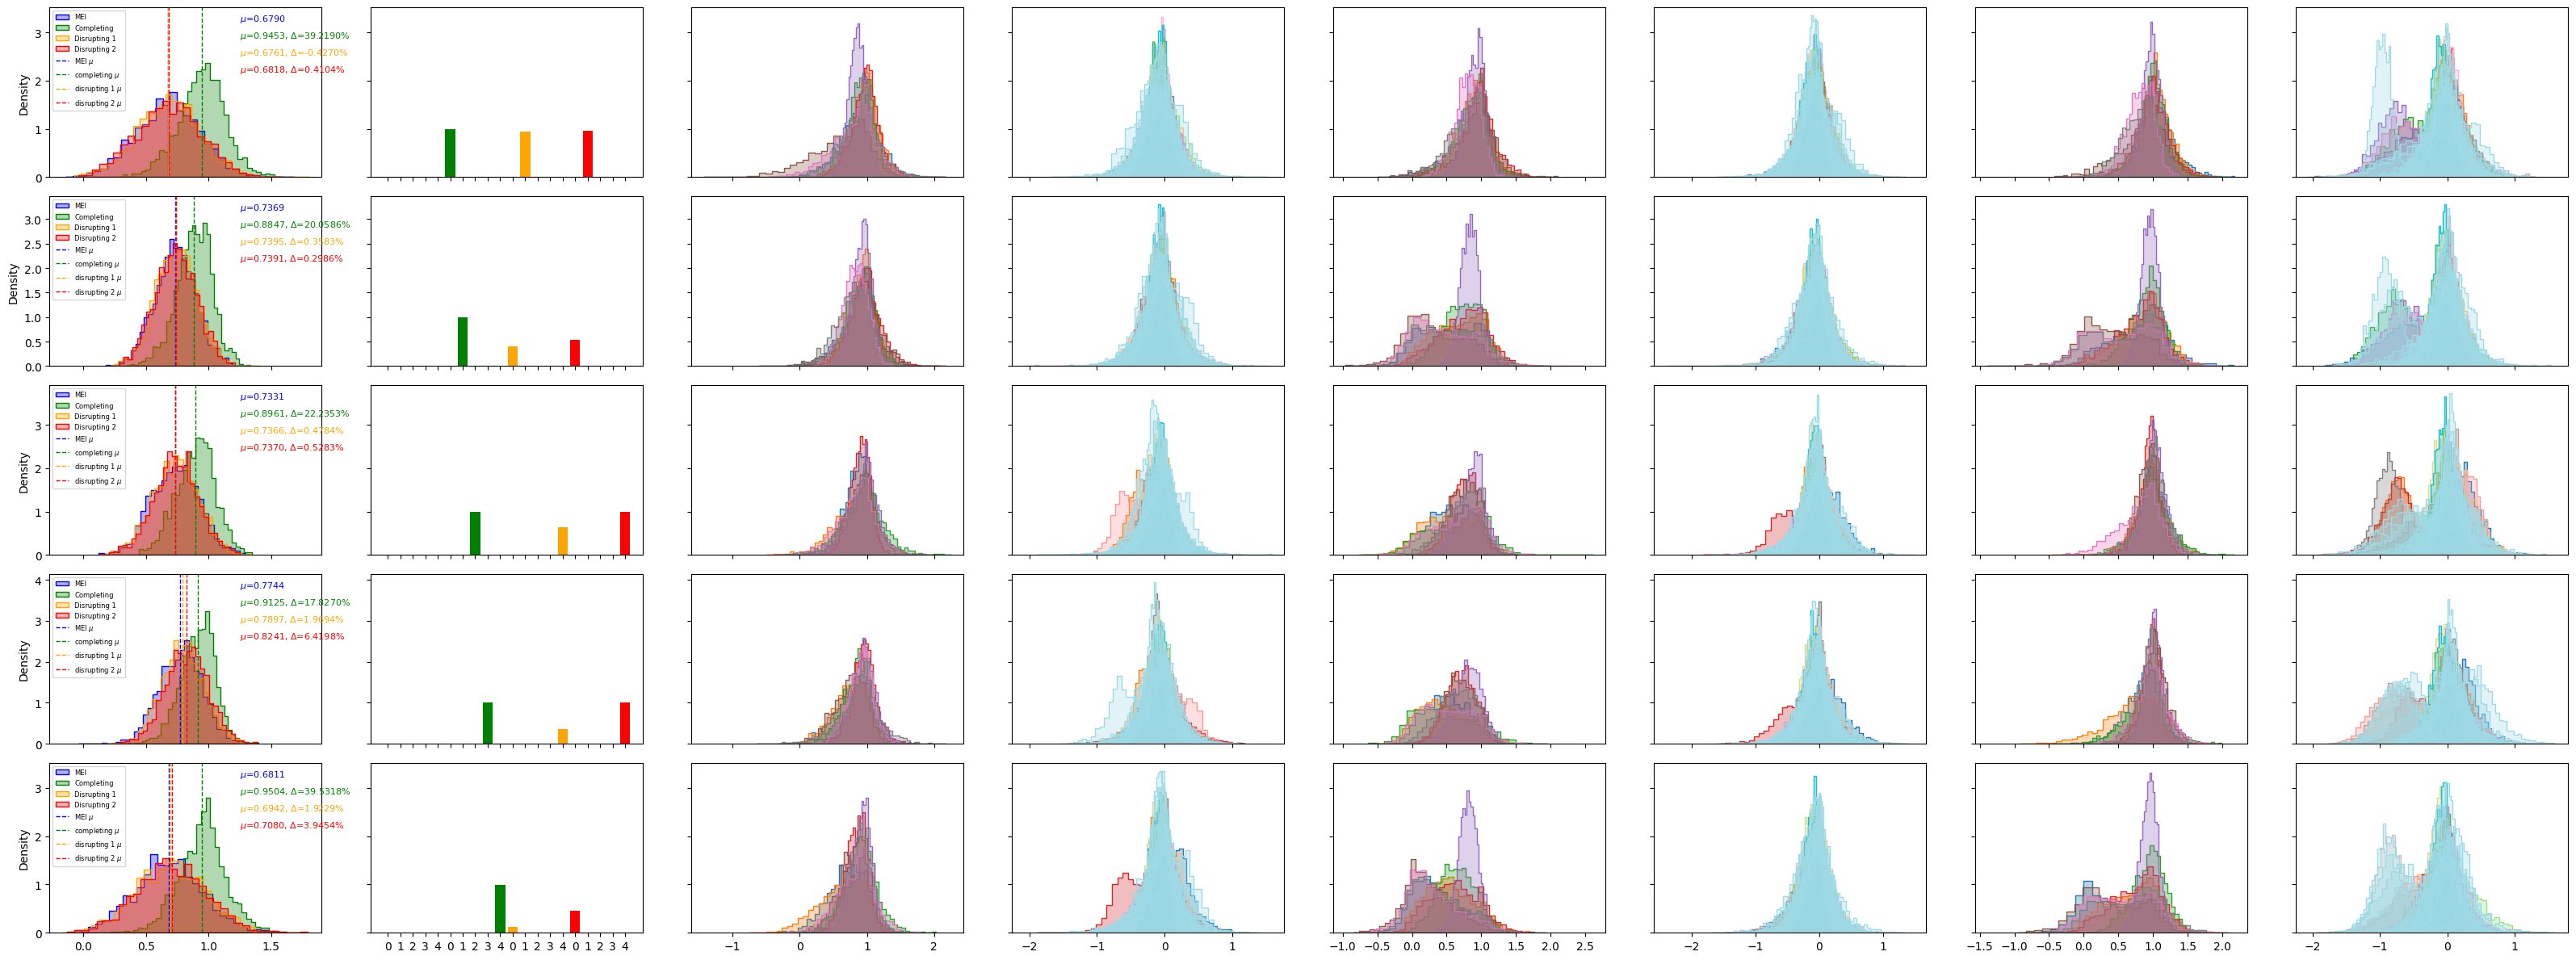

In [7]:
(
    all_idata,
    all_stimuli,
    average_exc,
    average_inh_1,
    average_inh_2,
    disrupting_pattern_indices,
) = exc_exponent_experiment(
    config_id=input_config["config_id"],
    seed=input_config["seed"],
    g_dim=input_config["g_dim"],
    g_prob=input_config["g_prob"],
    x_sigma=input_config["x_sigma"],
    i_sigma=input_config["i_sigma"],
    patterns_offset=input_config["patterns_offset"],
    g_x_exponent=input_config["g_x_exponent"],
    n_tune=input_config["n_tune"],
    n_draws=input_config["n_draws"],
    n_chains=input_config["n_chains"],
    n_cores=input_config["n_cores"],
    exc_fname=patterns_path,
    exc_image_ids=None
)

In [8]:
# results = (
#     all_idata,
#     all_stimuli,
#     average_exc,
#     average_inh_1,
#     average_inh_2,
#     disrupting_pattern_indices,
# )
# import pickle
# pickle.dump(results, open("results.pkl", "wb"))

[0, 2, 3, 4, 5, 7, 8, 9, 10, 12, 13, 14, 15, 17, 18, 19, 21, 22, 23, 24, 25, 27, 28, 29, 30, 32, 33, 34, 35, 37, 38, 39, 40, 42, 43, 44]
[1, 2, 3, 4, 6, 7, 8, 9, 11, 12, 13, 14, 16, 17, 18, 19, 20, 22, 23, 24, 26, 27, 28, 29, 31, 32, 33, 34, 36, 37, 38, 39, 41, 42, 43, 44]
[0, 1, 2, 3, 5, 6, 7, 8, 10, 11, 12, 13, 15, 16, 17, 18, 20, 21, 23, 24, 25, 26, 27, 28, 30, 31, 32, 33, 35, 36, 37, 38, 40, 41, 42, 43]
[0, 1, 2, 3, 5, 6, 7, 8, 10, 11, 12, 13, 15, 16, 17, 18, 20, 21, 22, 24, 25, 26, 27, 28, 30, 31, 32, 33, 35, 36, 37, 38, 40, 41, 42, 43]
[1, 2, 3, 4, 6, 7, 8, 9, 11, 12, 13, 14, 16, 17, 18, 19, 20, 21, 22, 23, 26, 27, 28, 29, 31, 32, 33, 34, 36, 37, 38, 39, 41, 42, 43, 44]


(<Figure size 1000x1600 with 10 Axes>,
 array([[<Axes: ylabel='Density'>, <Axes: >],
        [<Axes: ylabel='Density'>, <Axes: >],
        [<Axes: ylabel='Density'>, <Axes: >],
        [<Axes: ylabel='Density'>, <Axes: >],
        [<Axes: ylabel='Density'>, <Axes: >]], dtype=object),
 array([39.21903644, 20.05859315, 22.23531509, 17.82698135, 39.5318064 ]),
 array([-0.4269725 ,  0.35834257,  0.47836407,  1.96936222,  1.92287388]),
 array([0.41040689, 0.29864696, 0.52826563, 6.41975443, 3.94536189]))

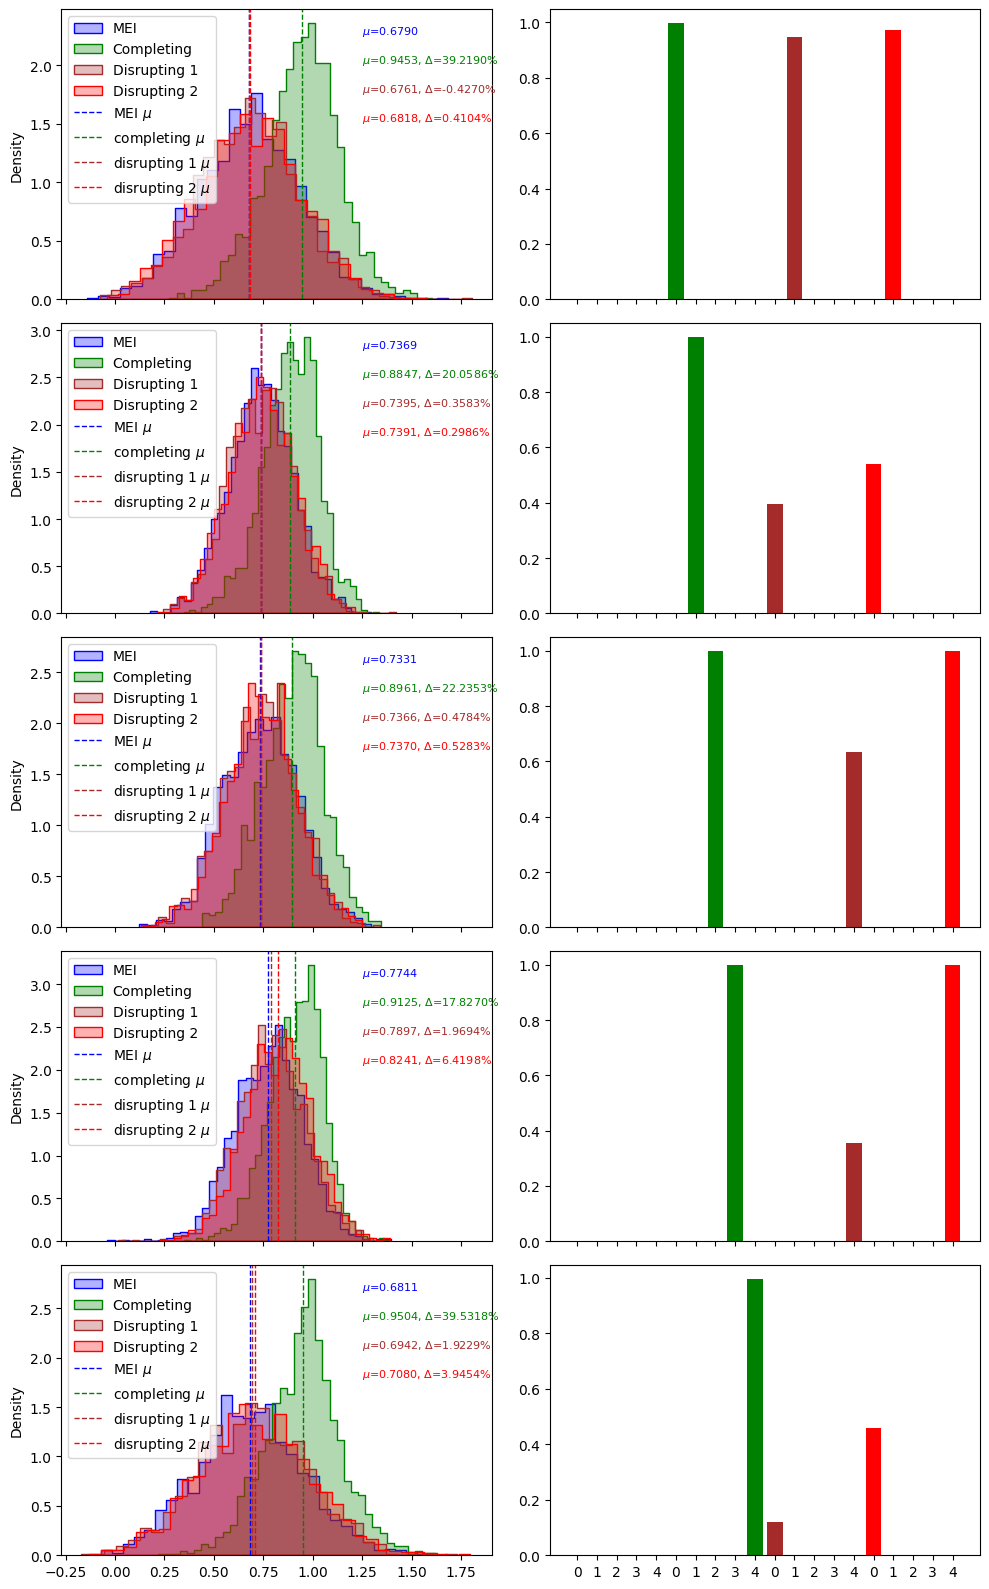

In [9]:
plot_posterior_half(all_idata=all_idata, disrupting_pattern_indices=disrupting_pattern_indices, G_dim=input_config["g_dim"])

In [10]:
all_idata

[[Inference data with groups:
  	> posterior
  	> sample_stats
  	> observed_data
  	> constant_data,
  Inference data with groups:
  	> posterior
  	> sample_stats
  	> observed_data
  	> constant_data,
  Inference data with groups:
  	> posterior
  	> sample_stats
  	> observed_data
  	> constant_data,
  Inference data with groups:
  	> posterior
  	> sample_stats
  	> observed_data
  	> constant_data],
 [Inference data with groups:
  	> posterior
  	> sample_stats
  	> observed_data
  	> constant_data,
  Inference data with groups:
  	> posterior
  	> sample_stats
  	> observed_data
  	> constant_data,
  Inference data with groups:
  	> posterior
  	> sample_stats
  	> observed_data
  	> constant_data,
  Inference data with groups:
  	> posterior
  	> sample_stats
  	> observed_data
  	> constant_data],
 [Inference data with groups:
  	> posterior
  	> sample_stats
  	> observed_data
  	> constant_data,
  Inference data with groups:
  	> posterior
  	> sample_stats
  	> observed_dat